# C.4 — Classification Risque ESG Multi-label

**ECE Paris — Ing4 IA Probabiliste, Théorie des Jeux & ML — Groupe 02**

---

## Contexte

L'investissement responsable est en pleine expansion : la réglementation européenne SFDR (Sustainable Finance Disclosure Regulation) et la taxonomie verte imposent aux acteurs financiers de classer leurs investissements selon leur impact ESG (Environnemental, Social, Gouvernance).

Ce projet développe un **système de classification multi-label** de documents financiers selon les critères ESG. Un même document peut simultanément aborder plusieurs piliers.

### Architecture du système

```
Document financier
      │
      ▼
  Chunking (2000 mots, overlap 20%)
      │
      ▼
  Mistral (LLM local via Ollama)
  ┌─── Extraction de mentions ESG
  ├─── Classification E / S / G
  ├─── Niveau de risque (faible→critique)
  └─── Citation + Confiance
      │
      ▼
  Agrégation par pilier
      │
      ▼
  Score de risque [0-1] + Label binaire
      │
      ▼
  Évaluation multi-label (Hamming, F1, P@k)
      │
      ▼
  Dashboard ESG
```

### Objectifs atteints

| Niveau | Objectif | Statut |
|--------|----------|--------|
| Minimum | Classification binaire par critère ESG avec LLM | ✅ |
| Bon | Classification multi-label + métriques complètes | ✅ |
| Excellent | Extraction de citations, agrégation entreprise, benchmark, dashboard | ✅ |

## 1. Installation et Configuration

In [1]:
# Installation des dépendances
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-r', 'requirements.txt', '-q'], check=True)

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from esg_classifier import ESGClassifier, ESGDocumentResult, CompanyESGProfile
from utils import (
    compute_all_metrics, print_metrics_report,
    generate_synthetic_dataset, get_company_documents, get_all_companies,
    hamming_loss, per_label_f1
)

# Dossier de résultats (créé automatiquement)
os.makedirs('results', exist_ok=True)

# Style matplotlib
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {'E': '#2ecc71', 'S': '#3498db', 'G': '#9b59b6'}

print('✅ Imports OK')
print('📊 Système ESG Multi-label prêt (Ollama / Mistral)')

✅ Imports OK
📊 Système ESG Multi-label prêt (Ollama / Mistral)


## 2. Génération du Dataset de Test

Dataset : 20 documents

Distribution des labels (ground truth) :
E    12
S     7
G     7
dtype: int64



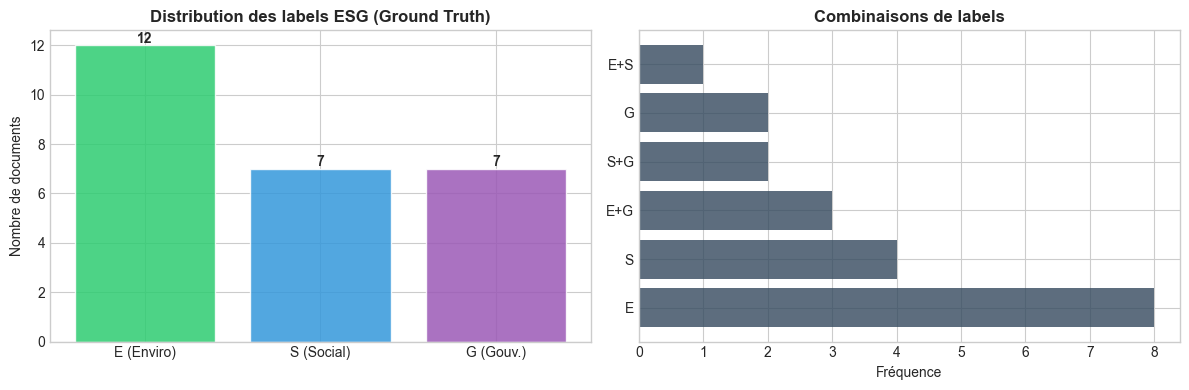


--- Exemple de document ---
ID: doc_010
Labels: {'E': False, 'S': True, 'G': True}
Scores ESG: {'E': 0.0, 'S': 0.75, 'G': 0.88}
Texte: Trois plaintes pour discrimination à l'embauche ont été déposées
        contre la filiale américaine. En parallèle, une enquête du régulateur SEC
        porte sur des irrégularités comptables dans l...


In [2]:
# Génération du dataset synthétique annoté
dataset = generate_synthetic_dataset(n_samples=20, seed=42)

print(f'Dataset : {len(dataset)} documents')
print()

# Distribution des labels
labels_df = pd.DataFrame([d['labels'] for d in dataset])
print('Distribution des labels (ground truth) :')
print(labels_df.sum())
print()

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart de distribution
counts = labels_df.sum()
axes[0].bar(['E (Enviro)', 'S (Social)', 'G (Gouv.)'], counts.values,
            color=[COLORS['E'], COLORS['S'], COLORS['G']], alpha=0.85, edgecolor='white')
axes[0].set_title('Distribution des labels ESG (Ground Truth)', fontweight='bold')
axes[0].set_ylabel('Nombre de documents')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 0.1, str(v), ha='center', fontweight='bold')

# Combinaisons de labels
combo_labels = []
for d in dataset:
    combo = '+'.join([k for k, v in d['labels'].items() if v]) or 'Aucun'
    combo_labels.append(combo)
combo_counts = pd.Series(combo_labels).value_counts()
axes[1].barh(combo_counts.index, combo_counts.values, color='#34495e', alpha=0.8)
axes[1].set_title('Combinaisons de labels', fontweight='bold')
axes[1].set_xlabel('Fréquence')

plt.tight_layout()
plt.savefig('results/dataset_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Exemple de document
print('\n--- Exemple de document ---')
ex = dataset[10]
print(f"ID: {ex['id']}")
print(f"Labels: {ex['labels']}")
print(f"Scores ESG: {ex['risk_scores']}")
print(f"Texte: {ex['text'][:200]}...")

## 3. Classification avec Mistral (Ollama)

> ⚠️ **Prérequis** : Ollama doit être en cours d'exécution (`ollama serve`) et le modèle Mistral téléchargé (`ollama pull mistral`).

In [3]:
# Initialisation du classifieur (Mistral via Ollama — 100% local)
classifier = ESGClassifier(model='mistral')

print('🔍 Classification ESG en cours...')
print('(Chaque document est envoyé à Mistral pour extraction de mentions ESG)')
print()

results = []
for i, doc in enumerate(dataset):
    print(f'  [{i+1:2d}/{len(dataset)}] {doc["id"]} : labels={doc["labels"]}...', end=' ')
    result = classifier.classify_document(doc['text'], doc['id'])
    results.append(result)
    print(f'→ {result.labels} ({len(result.mentions)} mentions, {result.processing_time:.1f}s)')

print(f'\n✅ Classification terminée pour {len(results)} documents')

🔍 Classification ESG en cours...
(Chaque document est envoyé à Mistral pour extraction de mentions ESG)

  [ 1/20] doc_000 : labels={'E': False, 'S': True, 'G': True}... → {'E': False, 'S': True, 'G': True} (2 mentions, 5.7s)
  [ 2/20] doc_001 : labels={'E': True, 'S': False, 'G': False}... → {'E': True, 'S': False, 'G': False} (2 mentions, 6.3s)
  [ 3/20] doc_002 : labels={'E': True, 'S': False, 'G': False}... → {'E': True, 'S': False, 'G': True} (3 mentions, 9.5s)
  [ 4/20] doc_003 : labels={'E': True, 'S': False, 'G': True}... → {'E': True, 'S': False, 'G': True} (3 mentions, 9.0s)
  [ 5/20] doc_004 : labels={'E': False, 'S': True, 'G': False}... → {'E': False, 'S': True, 'G': False} (2 mentions, 6.0s)
  [ 6/20] doc_005 : labels={'E': False, 'S': True, 'G': False}... → {'E': False, 'S': True, 'G': False} (1 mentions, 3.5s)
  [ 7/20] doc_006 : labels={'E': False, 'S': True, 'G': False}... → {'E': False, 'S': True, 'G': False} (1 mentions, 3.2s)
  [ 8/20] doc_007 : labels={'E': True, 

## 4. Analyse des Mentions Extraites

Total des mentions extraites : 46

    doc_id category                                         subcategory risk_level  confidence
0  doc_000        G  conseil_administration, remuneration, transparence      eleve        0.80
1  doc_000        S                                  conditions_travail     modere        0.70
2  doc_001        E                                             energie     faible        0.95
3  doc_001        E                                   emissions_carbone     modere        0.85
4  doc_002        E                                   emissions_carbone      eleve        0.90
5  doc_002        G                                        transparence     modere        0.80
6  doc_002        E                                 transition_energies      eleve        0.90
7  doc_003        E                                   emissions_carbone      eleve        0.90
8  doc_003        G                                        transparence      eleve        0.80
9  doc_003     

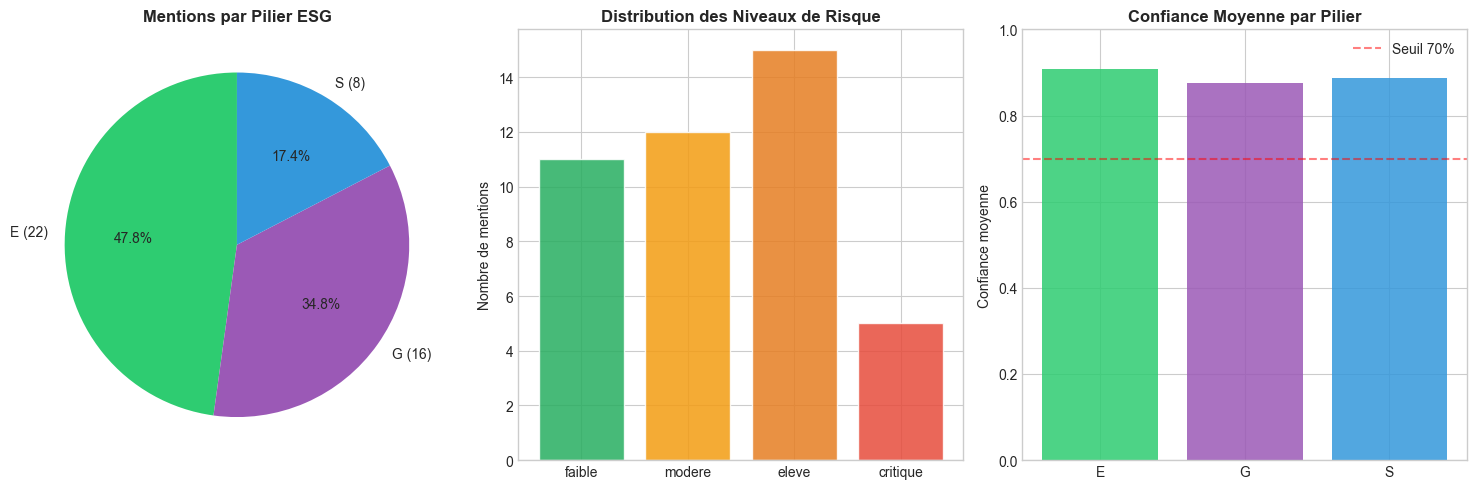


Top 10 sous-catégories les plus fréquentes :
subcategory
emissions_carbone                                     12
conditions_travail                                     7
transparence                                           7
energie                                                5
transition_energies                                    3
conseil_administration                                 3
conseil_administration, remuneration, transparence     2
rémunération                                           2
parite_femme-homme                                     1
eau                                                    1
Name: count, dtype: int64


In [4]:
# Compilation de toutes les mentions
all_mentions = []
for result in results:
    for mention in result.mentions:
        all_mentions.append({
            'doc_id': result.document_id,
            'category': mention.category,
            'subcategory': mention.subcategory,
            'risk_level': mention.risk_level,
            'confidence': mention.confidence,
            'citation': mention.citation[:100] + '...' if len(mention.citation) > 100 else mention.citation,
            'explanation': mention.explanation[:120],
        })

df_mentions = pd.DataFrame(all_mentions)
print(f'Total des mentions extraites : {len(df_mentions)}')
print()

if len(df_mentions) > 0:
    print(df_mentions[['doc_id', 'category', 'subcategory', 'risk_level', 'confidence']].head(10).to_string())

    # Visualisation des mentions
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # 1. Répartition par pilier
    cat_counts = df_mentions['category'].value_counts()
    axes[0].pie(cat_counts.values, labels=[f'{k} ({v})' for k, v in cat_counts.items()],
                colors=[COLORS.get(k, '#999') for k in cat_counts.index],
                autopct='%1.1f%%', startangle=90)
    axes[0].set_title('Mentions par Pilier ESG', fontweight='bold')

    # 2. Distribution des niveaux de risque
    risk_order = ['faible', 'modere', 'eleve', 'critique']
    risk_colors = ['#27ae60', '#f39c12', '#e67e22', '#e74c3c']
    risk_counts = df_mentions['risk_level'].value_counts().reindex(risk_order, fill_value=0)
    axes[1].bar(risk_order, risk_counts.values, color=risk_colors, alpha=0.85, edgecolor='white')
    axes[1].set_title('Distribution des Niveaux de Risque', fontweight='bold')
    axes[1].set_ylabel('Nombre de mentions')

    # 3. Confiance moyenne par catégorie
    conf_by_cat = df_mentions.groupby('category')['confidence'].mean()
    axes[2].bar(conf_by_cat.index, conf_by_cat.values,
                color=[COLORS.get(k, '#999') for k in conf_by_cat.index], alpha=0.85)
    axes[2].set_title('Confiance Moyenne par Pilier', fontweight='bold')
    axes[2].set_ylabel('Confiance moyenne')
    axes[2].set_ylim(0, 1)
    axes[2].axhline(0.7, color='red', linestyle='--', alpha=0.5, label='Seuil 70%')
    axes[2].legend()

    plt.tight_layout()
    plt.savefig('results/mentions_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Top sous-catégories
    print('\nTop 10 sous-catégories les plus fréquentes :')
    print(df_mentions['subcategory'].value_counts().head(10))
else:
    print('Aucune mention extraite. Vérifiez qu\'Ollama est en cours d\'exécution.')

## 5. Évaluation Multi-label (Niveau Bon)


  RAPPORT D'ÉVALUATION ESG MULTI-LABEL

Métrique                                Valeur
----------------------------------------------
Hamming Loss (↓ = meilleur)             0.0500
Subset Accuracy (exact match)           0.8500
F1 Macro                                0.9412
F1 Micro                                0.9455
Precision Macro                         0.9000
Recall Macro                            1.0000
Precision@1                             0.9500
Precision@2                             0.6500
Recall@1                                0.8000
Recall@2                                1.0000
Coverage Error (↓ = meilleur)           1.3500
LRAP (↑ = meilleur)                     0.9750

──────────────────────────────────────────────
  Métriques par label (E / S / G)
──────────────────────────────────────────────

  [E]
    Precision : 1.0000
    Recall    : 1.0000
    F1        : 1.0000
    Support   : 12 exemples

  [S]
    Precision : 1.0000
    Recall    : 1.0000
    F1        :

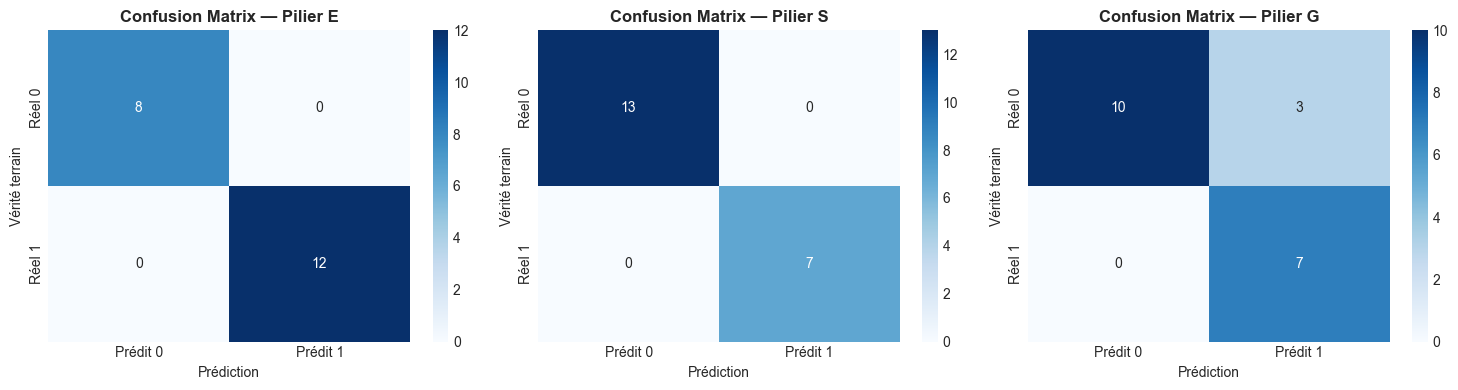

In [5]:
# Construction des matrices y_true et y_pred
label_names = ['E', 'S', 'G']

y_true = np.array([
    [int(d['labels']['E']), int(d['labels']['S']), int(d['labels']['G'])]
    for d in dataset
])

y_pred = np.array([
    [int(r.labels['E']), int(r.labels['S']), int(r.labels['G'])]
    for r in results
])

y_scores = np.array([
    [r.risk_scores['E'], r.risk_scores['S'], r.risk_scores['G']]
    for r in results
])

# Calcul des métriques
metrics = compute_all_metrics(y_true, y_pred, y_scores, label_names)
print_metrics_report(metrics, label_names)

# Matrice de confusion par label
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, label in enumerate(label_names):
    cm = confusion_matrix(y_true[:, idx], y_pred[:, idx])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Prédit 0', 'Prédit 1'],
                yticklabels=['Réel 0', 'Réel 1'])
    axes[idx].set_title(f'Confusion Matrix — Pilier {label}', fontweight='bold')
    axes[idx].set_xlabel('Prédiction')
    axes[idx].set_ylabel('Vérité terrain')

plt.tight_layout()
plt.savefig('results/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

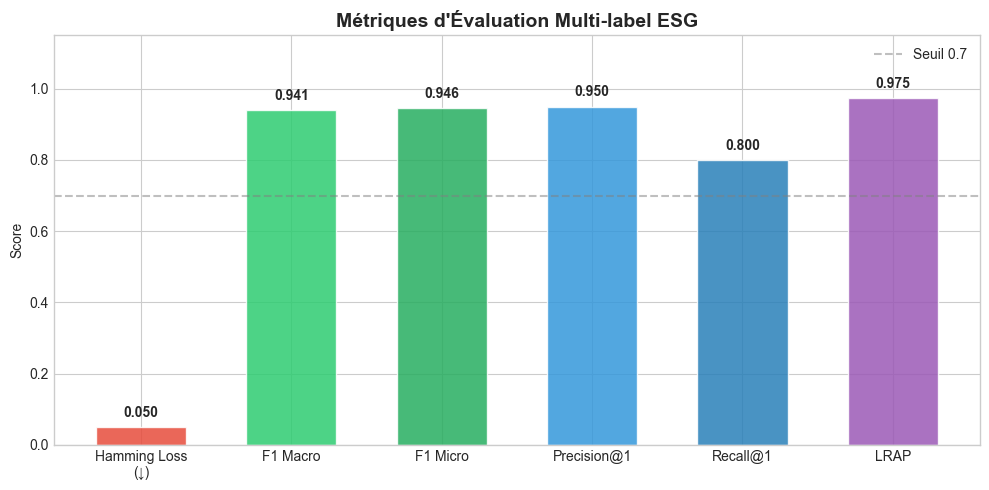

In [6]:
# Visualisation des métriques clés
metric_names = ['Hamming Loss\n(↓)', 'F1 Macro', 'F1 Micro', 'Precision@1', 'Recall@1', 'LRAP']
metric_values = [
    metrics.hamming_loss,
    metrics.f1_macro,
    metrics.f1_micro,
    metrics.precision_at_1,
    metrics.recall_at_1,
    metrics.label_ranking_avg_precision
]
colors_bar = ['#e74c3c', '#2ecc71', '#27ae60', '#3498db', '#2980b9', '#9b59b6']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(metric_names, metric_values, color=colors_bar, alpha=0.85, edgecolor='white', width=0.6)
ax.set_ylim(0, 1.15)
ax.set_title('Métriques d\'Évaluation Multi-label ESG', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.axhline(0.7, color='gray', linestyle='--', alpha=0.5, label='Seuil 0.7')
ax.legend()
for bar, val in zip(bars, metric_values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.3f}',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('results/evaluation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Agrégation au Niveau Entreprise (Niveau Excellent)

In [7]:
companies = get_all_companies()
company_profiles = []

print('🏢 Analyse ESG par entreprise...')
for company_info in companies:
    print(f'\n  Entreprise : {company_info["name"]} ({company_info["sector"]})')
    docs = get_company_documents(company_info)
    profile = classifier.classify_company(company_info['name'], docs)
    company_profiles.append(profile)
    print(f'  → Scores agrégés : {profile.aggregated_scores}')
    print(f'  → Risque global : {profile.overall_risk} | Rating ESG : {profile.esg_rating}')

print('\n✅ Profils ESG générés pour toutes les entreprises')

🏢 Analyse ESG par entreprise...

  Entreprise : TotalEnergies SA (Énergie)
  Analyse de 'TotalEnergies_doc_1'...
  Analyse de 'TotalEnergies_doc_2'...
  Analyse de 'TotalEnergies_doc_3'...
  → Scores agrégés : {'E': 0.72, 'S': 0.625, 'G': 0.445}
  → Risque global : eleve | Rating ESG : B

  Entreprise : Schneider Electric SE (Industrie)
  Analyse de 'Schneider_doc_1'...
  Analyse de 'Schneider_doc_2'...
  Analyse de 'Schneider_doc_3'...
  → Scores agrégés : {'E': 0.2, 'S': 0.19, 'G': 0.19}
  → Risque global : faible | Rating ESG : BBB

  Entreprise : Danone SA (Agroalimentaire)
  Analyse de 'Danone_doc_1'...
  Analyse de 'Danone_doc_2'...
  Analyse de 'Danone_doc_3'...
  → Scores agrégés : {'E': 0.307, 'S': 1.0, 'G': 0.49}
  → Risque global : critique | Rating ESG : CCC

  Entreprise : BNP Paribas SA (Finance)
  Analyse de 'BNP_doc_1'...
  Analyse de 'BNP_doc_2'...
  Analyse de 'BNP_doc_3'...
  → Scores agrégés : {'E': 0.4, 'S': 0.625, 'G': 0.605}
  → Risque global : eleve | Rating ESG

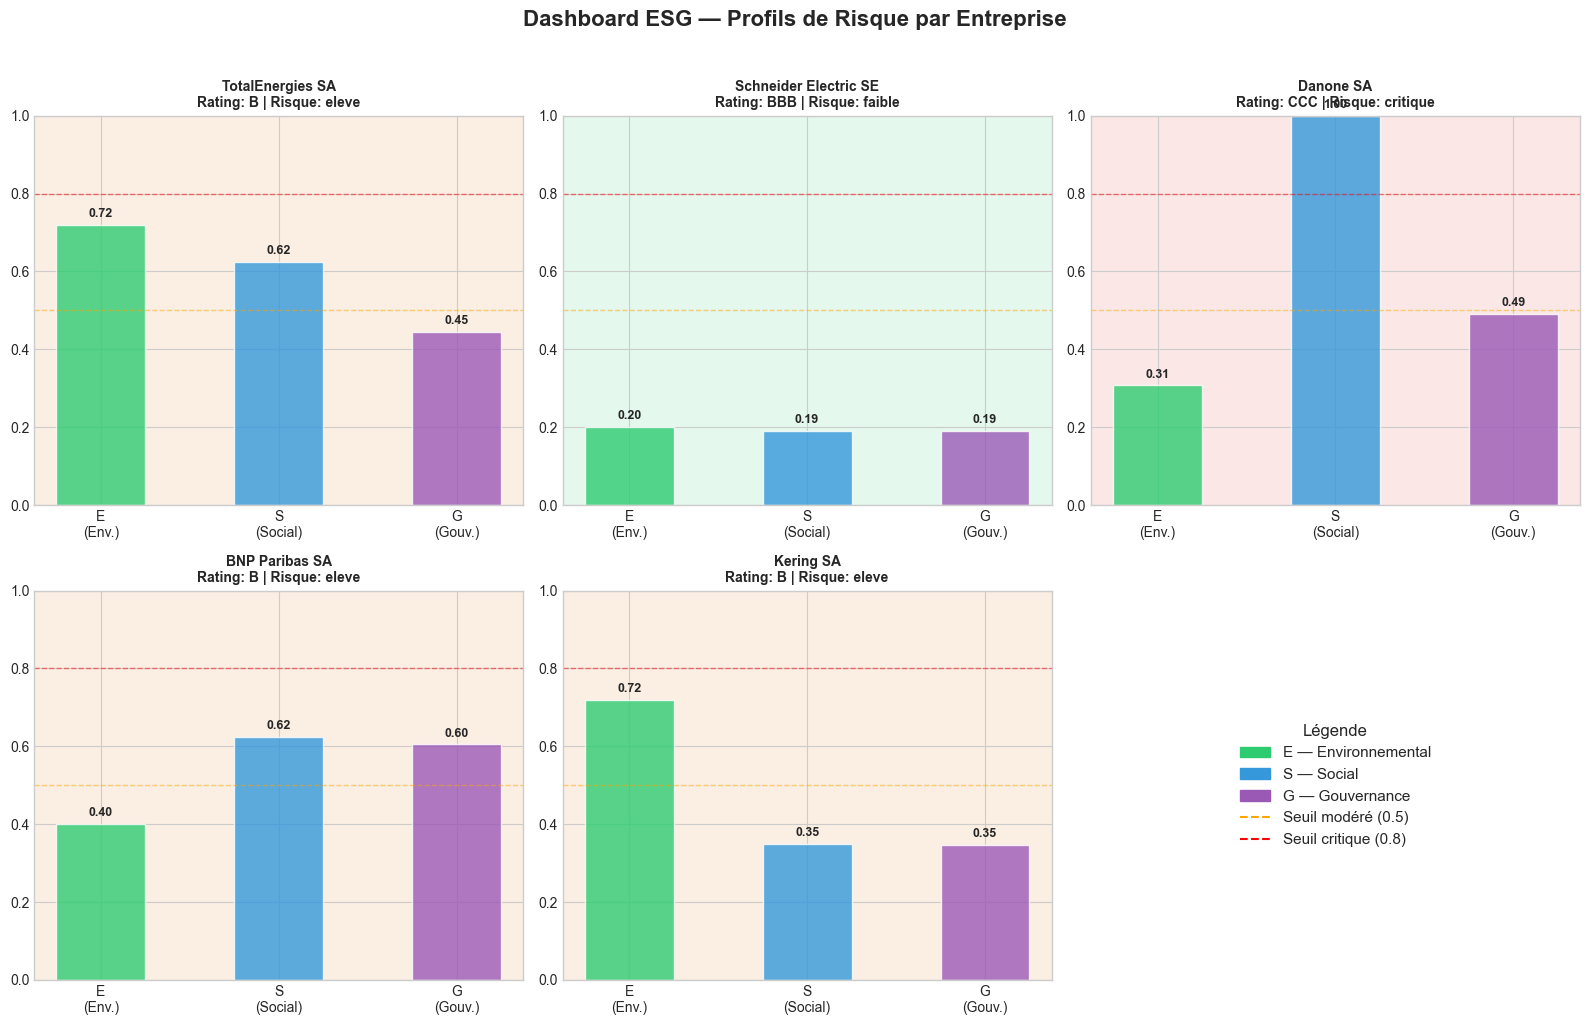

In [8]:
# Dashboard entreprise
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

risk_colors_map = {
    'negligeable': '#27ae60', 'faible': '#2ecc71',
    'modere': '#f39c12', 'eleve': '#e67e22', 'critique': '#e74c3c'
}

for i, profile in enumerate(company_profiles):
    ax = axes[i]
    scores = profile.aggregated_scores
    cats = ['E\n(Env.)', 'S\n(Social)', 'G\n(Gouv.)']
    vals = [scores.get('E', 0), scores.get('S', 0), scores.get('G', 0)]
    bar_colors = [COLORS['E'], COLORS['S'], COLORS['G']]

    bars = ax.bar(cats, vals, color=bar_colors, alpha=0.8, edgecolor='white', width=0.5)
    ax.set_ylim(0, 1)
    ax.set_title(f'{profile.company_name}\nRating: {profile.esg_rating} | Risque: {profile.overall_risk}',
                 fontweight='bold', fontsize=10)
    ax.axhline(0.5, color='orange', linestyle='--', alpha=0.5, linewidth=1)
    ax.axhline(0.8, color='red', linestyle='--', alpha=0.5, linewidth=1)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.2f}',
                ha='center', fontsize=9, fontweight='bold')

    bg_color = risk_colors_map.get(profile.overall_risk, 'white')
    ax.set_facecolor(bg_color + '20')

# Légende commune (dernière case)
axes[-1].axis('off')
legend_elements = [
    mpatches.Patch(color=COLORS['E'], label='E — Environnemental'),
    mpatches.Patch(color=COLORS['S'], label='S — Social'),
    mpatches.Patch(color=COLORS['G'], label='G — Gouvernance'),
    plt.Line2D([0], [0], color='orange', linestyle='--', label='Seuil modéré (0.5)'),
    plt.Line2D([0], [0], color='red', linestyle='--', label='Seuil critique (0.8)'),
]
axes[-1].legend(handles=legend_elements, loc='center', fontsize=11,
                title='Légende', title_fontsize=12)

fig.suptitle('Dashboard ESG — Profils de Risque par Entreprise',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('results/company_esg_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()


📊 TABLEAU COMPARATIF ESG
           Entreprise  Score E  Score S  Score G  Score Moyen Risque Global Rating ESG  Nb Documents
            Danone SA    0.307    1.000    0.490        0.599      critique        CCC             3
     TotalEnergies SA    0.720    0.625    0.445        0.597         eleve          B             3
       BNP Paribas SA    0.400    0.625    0.605        0.543         eleve          B             3
            Kering SA    0.720    0.350    0.347        0.472         eleve          B             3
Schneider Electric SE    0.200    0.190    0.190        0.193        faible        BBB             3


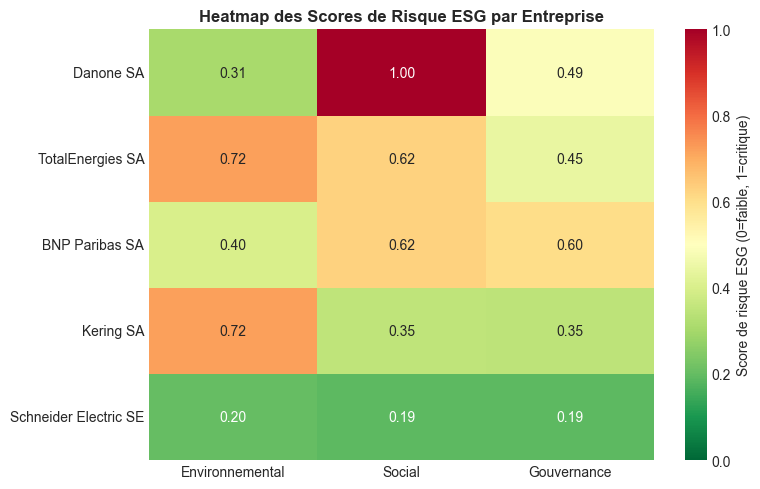

In [9]:
# Tableau comparatif final
summary_data = []
for p in company_profiles:
    summary_data.append({
        'Entreprise': p.company_name,
        'Score E': p.aggregated_scores.get('E', 0),
        'Score S': p.aggregated_scores.get('S', 0),
        'Score G': p.aggregated_scores.get('G', 0),
        'Score Moyen': round(np.mean(list(p.aggregated_scores.values())), 3),
        'Risque Global': p.overall_risk,
        'Rating ESG': p.esg_rating,
        'Nb Documents': len(p.documents),
    })

df_summary = pd.DataFrame(summary_data).sort_values('Score Moyen', ascending=False)
print('\n📊 TABLEAU COMPARATIF ESG')
print('='*90)
print(df_summary.to_string(index=False))

# Heatmap des scores
fig, ax = plt.subplots(figsize=(8, 5))
heatmap_data = df_summary[['Score E', 'Score S', 'Score G']].values
sns.heatmap(heatmap_data,
            xticklabels=['Environnemental', 'Social', 'Gouvernance'],
            yticklabels=df_summary['Entreprise'].values,
            annot=True, fmt='.2f', cmap='RdYlGn_r',
            vmin=0, vmax=1, ax=ax,
            cbar_kws={'label': 'Score de risque ESG (0=faible, 1=critique)'})
ax.set_title('Heatmap des Scores de Risque ESG par Entreprise', fontweight='bold')
plt.tight_layout()
plt.savefig('results/esg_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Benchmark contre Annotations Humaines (Niveau Excellent)

  BENCHMARK : Mistral LLM vs Annotateur Humain (simulé)

Métrique                        Mistral LLM       Humain
-------------------------------------------------------
Hamming Loss (↓)                     0.0500       0.1667
F1 E                                 1.0000       0.8571 ✅
F1 S                                 1.0000       0.7500 ✅
F1 G                                 0.8235       0.8000 ✅

Accord LLM/Humain                    0.7833


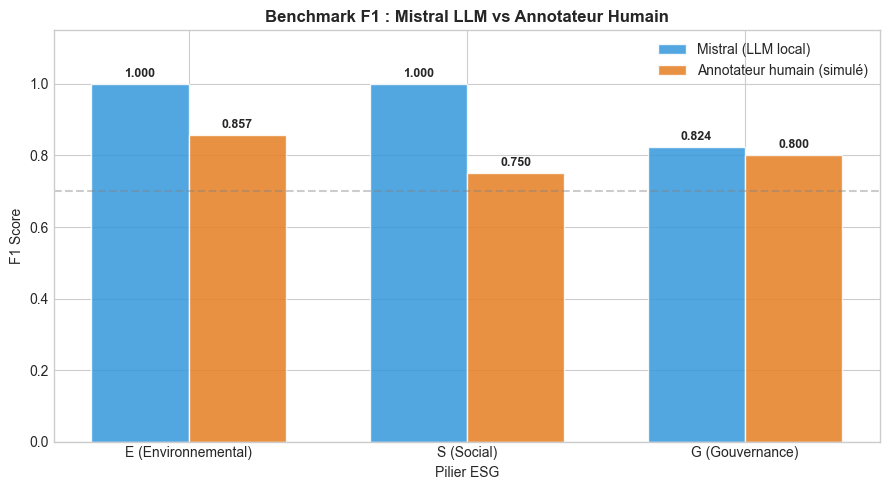

In [10]:
# Simulation d'un benchmark inter-annotateur
# (En conditions réelles, on utiliserait de vraies annotations humaines)
np.random.seed(42)

# Annotateur humain simulé avec 85% d'accord avec la vérité terrain
human_pred = y_true.copy().astype(float)
flip_mask = np.random.random(human_pred.shape) < 0.15
human_pred[flip_mask] = 1 - human_pred[flip_mask]
human_pred = human_pred.astype(int)

print('='*65)
print('  BENCHMARK : Mistral LLM vs Annotateur Humain (simulé)')
print('='*65)

hl_llm   = hamming_loss(y_true, y_pred)
hl_human = hamming_loss(y_true, human_pred)

f1_llm   = per_label_f1(y_true, y_pred,   label_names)
f1_human = per_label_f1(y_true, human_pred, label_names)

print(f"\n{'Métrique':<30} {'Mistral LLM':>12} {'Humain':>12}")
print('-'*55)
print(f"{'Hamming Loss (↓)':<30} {hl_llm:>12.4f} {hl_human:>12.4f}")
for label in label_names:
    f1_l = f1_llm[label]['f1']
    f1_h = f1_human[label]['f1']
    diff = '✅' if f1_l >= f1_h else '⚠️'
    print(f"{'F1 ' + label:<30} {f1_l:>12.4f} {f1_h:>12.4f} {diff}")

agreement = np.mean(y_pred == human_pred)
print(f"\n{'Accord LLM/Humain':<30} {agreement:>12.4f}")

# Visualisation comparative
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(label_names))
width = 0.35

f1_vals_llm   = [f1_llm[l]['f1']   for l in label_names]
f1_vals_human = [f1_human[l]['f1'] for l in label_names]

bars1 = ax.bar(x - width/2, f1_vals_llm, width, label='Mistral (LLM local)',
               color='#3498db', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, f1_vals_human, width, label='Annotateur humain (simulé)',
               color='#e67e22', alpha=0.85, edgecolor='white')

ax.set_xlabel('Pilier ESG')
ax.set_ylabel('F1 Score')
ax.set_title('Benchmark F1 : Mistral LLM vs Annotateur Humain', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['E (Environnemental)', 'S (Social)', 'G (Gouvernance)'])
ax.set_ylim(0, 1.15)
ax.legend()
ax.axhline(0.7, color='gray', linestyle='--', alpha=0.4)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('results/benchmark_human_llm.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Export des Résultats

In [11]:
# Export JSON des résultats complets
export_data = {
    'metadata': {
        'project': 'C4 - Classification ESG Multi-label',
        'model': 'mistral (Ollama local)',
        'n_documents': len(results),
        'n_companies': len(company_profiles),
    },
    'global_metrics': {
        'hamming_loss': metrics.hamming_loss,
        'f1_macro': metrics.f1_macro,
        'f1_micro': metrics.f1_micro,
        'precision_at_1': metrics.precision_at_1,
        'recall_at_1': metrics.recall_at_1,
        'lrap': metrics.label_ranking_avg_precision,
        'per_label': metrics.per_label_f1,
    },
    'companies': [
        {
            'name': p.company_name,
            'scores': p.aggregated_scores,
            'overall_risk': p.overall_risk,
            'rating': p.esg_rating,
            'n_documents': len(p.documents),
        }
        for p in company_profiles
    ]
}

with open('results/esg_results.json', 'w', encoding='utf-8') as f:
    json.dump(export_data, f, ensure_ascii=False, indent=2)

print('✅ Résultats exportés dans results/esg_results.json')

# Export CSV des mentions
if len(df_mentions) > 0:
    df_mentions.to_csv('results/esg_mentions.csv', index=False, encoding='utf-8')
    print('✅ Mentions exportées dans results/esg_mentions.csv')

print('\n📁 Fichiers générés dans le dossier results/ :')
import os
for f in sorted(os.listdir('results')):
    size = os.path.getsize(f'results/{f}')
    print(f'   {f}  ({size:,} octets)')

✅ Résultats exportés dans results/esg_results.json
✅ Mentions exportées dans results/esg_mentions.csv

📁 Fichiers générés dans le dossier results/ :
   benchmark_human_llm.png  (43,626 octets)
   company_esg_dashboard.png  (124,088 octets)
   confusion_matrices.png  (39,783 octets)
   dataset_distribution.png  (41,264 octets)
   esg_heatmap.png  (62,562 octets)
   esg_mentions.csv  (11,795 octets)
   esg_results.json  (1,831 octets)
   evaluation_metrics.png  (41,915 octets)
   mentions_analysis.png  (76,990 octets)
